In [1]:
import sys
from pathlib import Path

notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent

sys.path.append(str(parent_dir))

%load_ext autoreload
%autoreload 2

In [2]:
import boto3
from os import getenv
import json
from pprint import pprint
import awswrangler as wr
import pandas as pd
from sqlalchemy import text
from datetime import datetime, date
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

from sqlalchemy import create_engine
import base64
from io import BytesIO

%matplotlib inline

In [3]:
session = boto3.Session(profile_name='SA', region_name='eu-central-1')

In [4]:
POSTHOG_QUERY= """SELECT up.timestamp, up.properties, up.distinct_id
FROM usage.posthog up 
WHERE up.event = 'dashboard_viewed';"""

In [5]:
posthog = wr.athena.read_sql_query(
            sql=POSTHOG_QUERY,
            database="usage",
            s3_output="s3://slimwonen-athena-queries/",
            workgroup="primary",
            boto3_session=session,
        )

In [6]:
posthog.shape

(505701, 3)

In [7]:
def add_household(row: pd.Series) -> pd.Series:
    props = json.loads(row['properties'])
    if 'household_id' in props:
        row['household_id'] = props['household_id']
    return row

In [8]:
posthog = posthog.apply(add_household, axis=1)
logins = posthog.groupby('household_id').count().reset_index()
# posthog.groupby('distinct_id').count().reset_index() => many more un_authenticated users, why??

In [9]:
df = posthog[['timestamp', 'household_id']].rename(columns={'household_id': 'id'})
df = df[df['id'] != 'un_authenticated']

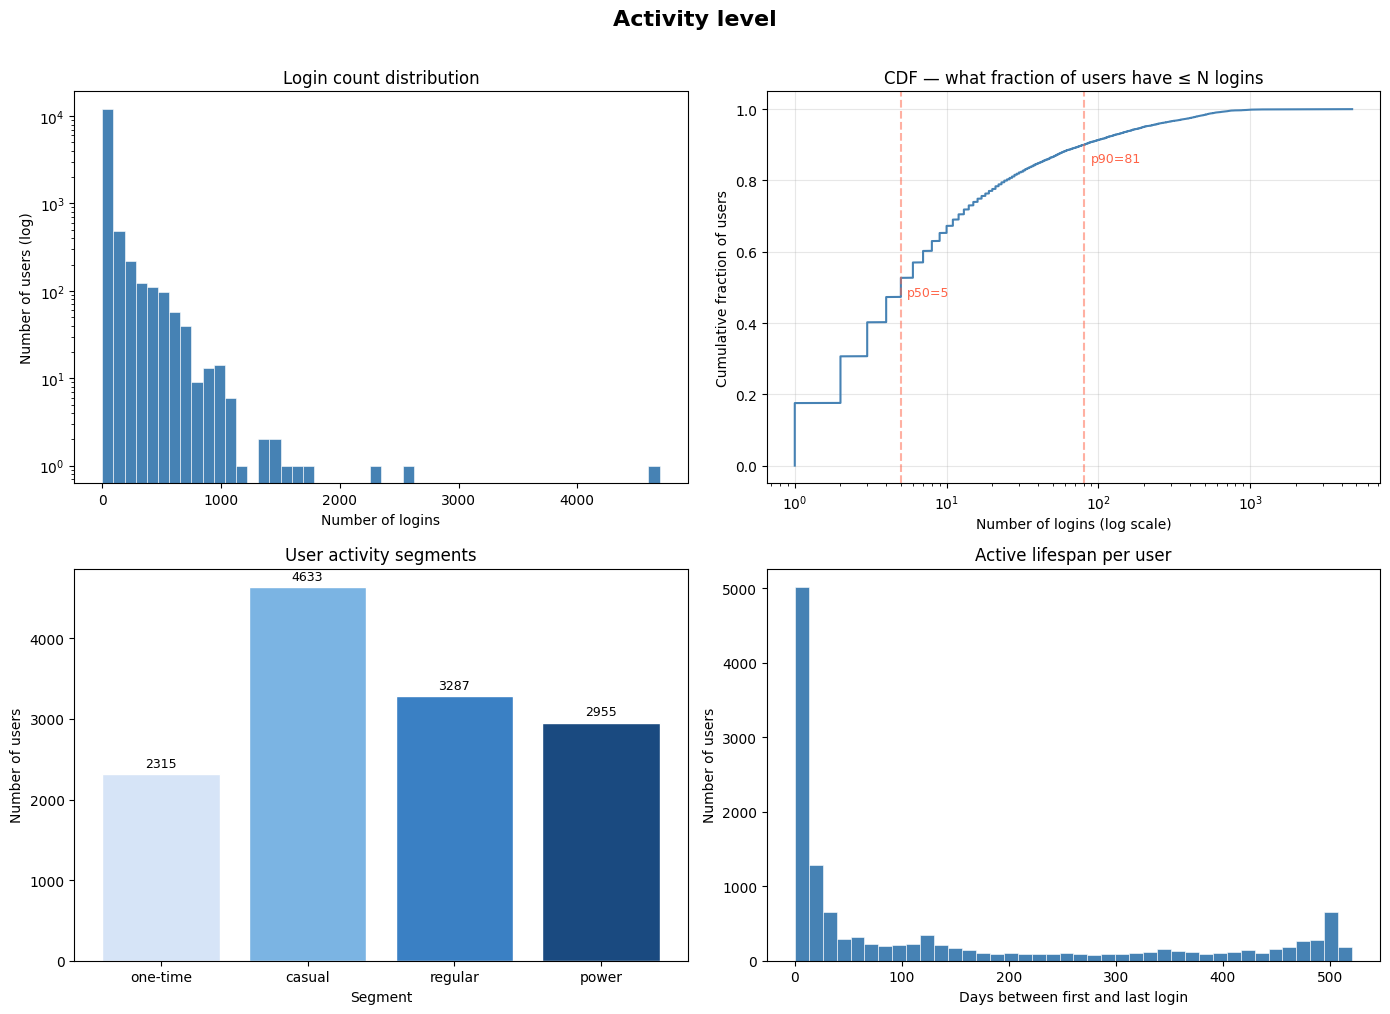

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Assume your dataframe is called df with columns: id, timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['id', 'timestamp'])

# ── Derived columns used across plots
logins_per_user = df.groupby('id').size().rename('n_logins')
first_last = df.groupby('id')['timestamp'].agg(['min', 'max'])
first_last['lifespan_days'] = (first_last['max'] - first_last['min']).dt.days

# Session gaps (per user, consecutive logins)
df['prev_ts'] = df.groupby('id')['timestamp'].shift(1)
df['gap_hours'] = (df['timestamp'] - df['prev_ts']).dt.total_seconds() / 3600

# Activity segments
def segment(n):
    if n == 1:   return 'one-time'
    if n <= 5:   return 'casual'
    if n <= 20:  return 'regular'
    return 'power'

user_segments = logins_per_user.apply(segment).value_counts()
seg_order = ['one-time', 'casual', 'regular', 'power']
user_segments = user_segments.reindex(seg_order, fill_value=0)

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Activity level deep-dive (2×2)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Activity level', fontsize=16, fontweight='bold', y=1.01)

# 1a. Histogram of login counts (log scale on y to handle heavy tail)
ax = axes[0, 0]
ax.hist(logins_per_user, bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_yscale('log')
ax.set_xlabel('Number of logins')
ax.set_ylabel('Number of users (log)')
ax.set_title('Login count distribution')

# 1b. CDF of login counts
ax = axes[0, 1]
sorted_logins = np.sort(logins_per_user)
cdf = np.arange(1, len(sorted_logins) + 1) / len(sorted_logins)
ax.plot(sorted_logins, cdf, color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('Number of logins (log scale)')
ax.set_ylabel('Cumulative fraction of users')
ax.set_title('CDF — what fraction of users have ≤ N logins')
ax.grid(True, alpha=0.3)

# Annotate median and 90th percentile
for pct, label in [(50, 'p50'), (90, 'p90')]:
    v = np.percentile(sorted_logins, pct)
    c = np.interp(v, sorted_logins, cdf)
    ax.axvline(v, linestyle='--', alpha=0.5, color='tomato')
    ax.text(v * 1.1, c - 0.05, f'{label}={v:.0f}', fontsize=9, color='tomato')

# 1c. User activity segments
ax = axes[1, 0]
colors = ['#d6e4f7', '#7bb4e3', '#3a80c4', '#1a4a80']
bars = ax.bar(seg_order, user_segments[seg_order], color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
ax.set_xlabel('Segment')
ax.set_ylabel('Number of users')
ax.set_title('User activity segments')

# 1d. Active lifespan per user (first → last login)
ax = axes[1, 1]
ax.hist(first_last['lifespan_days'], bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Days between first and last login')
ax.set_ylabel('Number of users')
ax.set_title('Active lifespan per user')

plt.tight_layout()
plt.savefig('activity_levels.png', dpi=150, bbox_inches='tight')
plt.show()

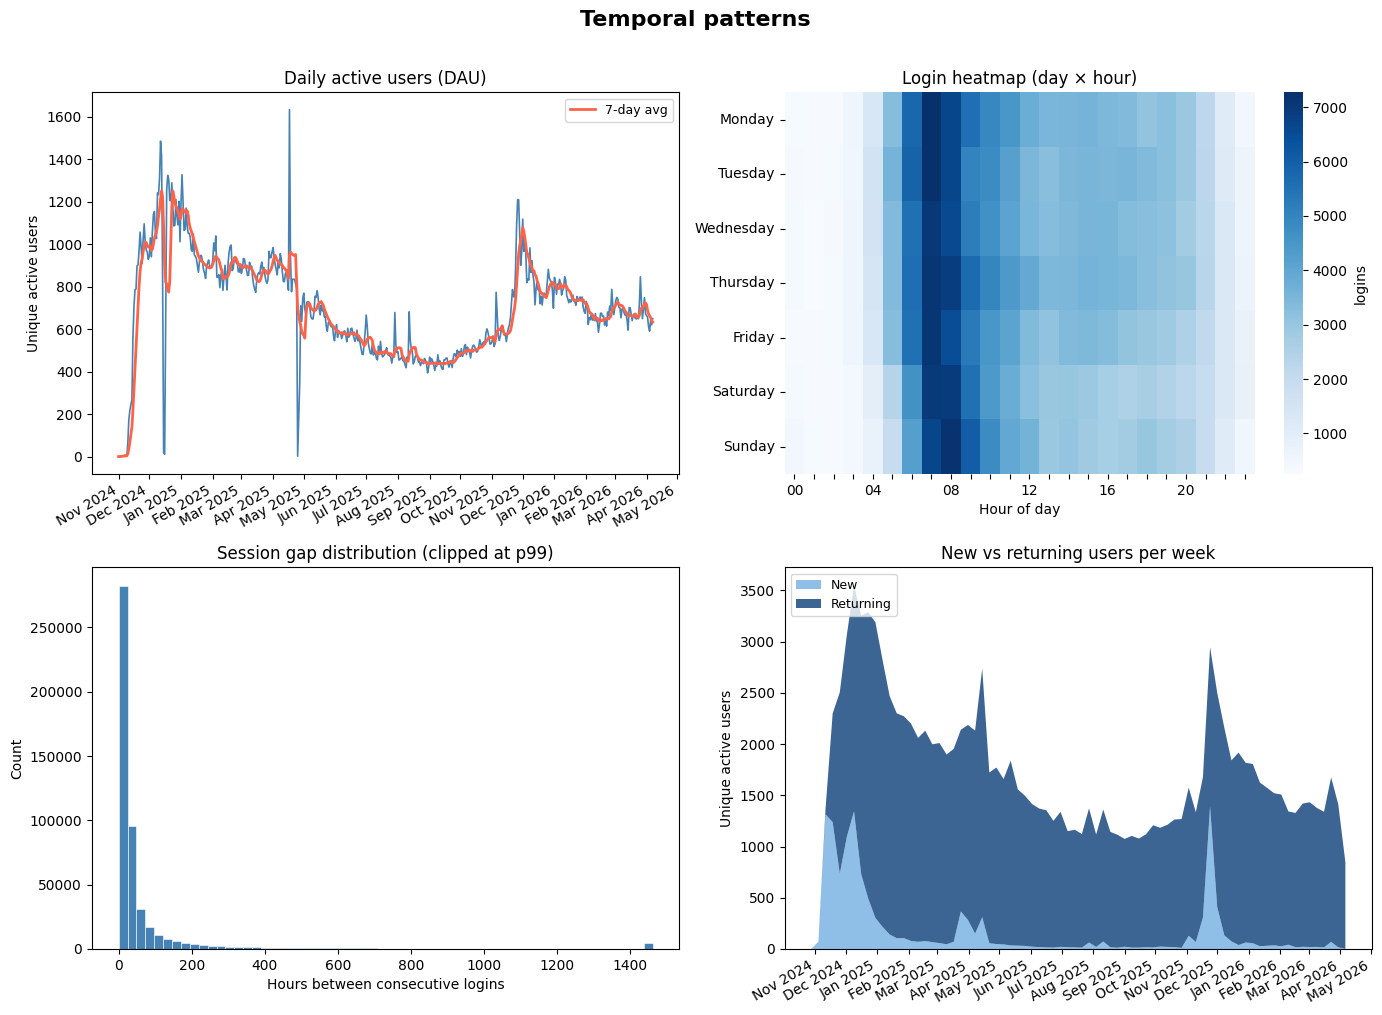

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Temporal patterns (2×2)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Temporal patterns', fontsize=16, fontweight='bold', y=1.01)

# 2a. Daily active users (DAU)
ax = axes[0, 0]
dau = df.groupby(df['timestamp'].dt.date)['id'].nunique()
dau.index = pd.to_datetime(dau.index)
ax.plot(dau.index, dau.values, linewidth=1.2, color='steelblue')
# 7-day rolling average overlay
rolling = dau.rolling(7, min_periods=1).mean()
ax.plot(rolling.index, rolling.values, linewidth=2, color='tomato', label='7-day avg')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel('Unique active users')
ax.set_title('Daily active users (DAU)')
ax.legend(fontsize=9)

# 2b. Hour-of-day × day-of-week heatmap
ax = axes[0, 1]
df['hour'] = df['timestamp'].dt.hour
df['dow']  = df['timestamp'].dt.day_name()
dow_order  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pivot = df.groupby(['dow', 'hour']).size().unstack(fill_value=0)
pivot = pivot.reindex(dow_order)
sns.heatmap(pivot, ax=ax, cmap='Blues', linewidths=0,
            xticklabels=[f'{h:02d}' if h % 4 == 0 else '' for h in range(24)],
            cbar_kws={'label': 'logins'})
ax.set_xlabel('Hour of day')
ax.set_ylabel('')
ax.set_title('Login heatmap (day × hour)')

# 2c. Session gap distribution
ax = axes[1, 0]
gaps = df['gap_hours'].dropna()
gaps_clipped = gaps.clip(upper=gaps.quantile(0.99))  # clip extreme outliers for readability
ax.hist(gaps_clipped, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Hours between consecutive logins')
ax.set_ylabel('Count')
ax.set_title('Session gap distribution (clipped at p99)')

# 2d. New vs returning users per week (stacked area)
ax = axes[1, 1]
df['week'] = df['timestamp'].dt.to_period('W').dt.start_time
first_seen = df.groupby('id')['timestamp'].min().rename('first_seen')
df = df.join(first_seen, on='id')
df['is_new'] = df['timestamp'].dt.to_period('W') == df['first_seen'].dt.to_period('W')
weekly = df.groupby('week').agg(
    new_users    = ('id', lambda x: x[df.loc[x.index, 'is_new']].nunique()),
    return_users = ('id', lambda x: x[~df.loc[x.index, 'is_new']].nunique()),
)
ax.stackplot(weekly.index, weekly['new_users'], weekly['return_users'],
             labels=['New', 'Returning'], colors=['#7bb4e3', '#1a4a80'], alpha=0.85)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_ylabel('Unique active users')
ax.set_title('New vs returning users per week')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('temporal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

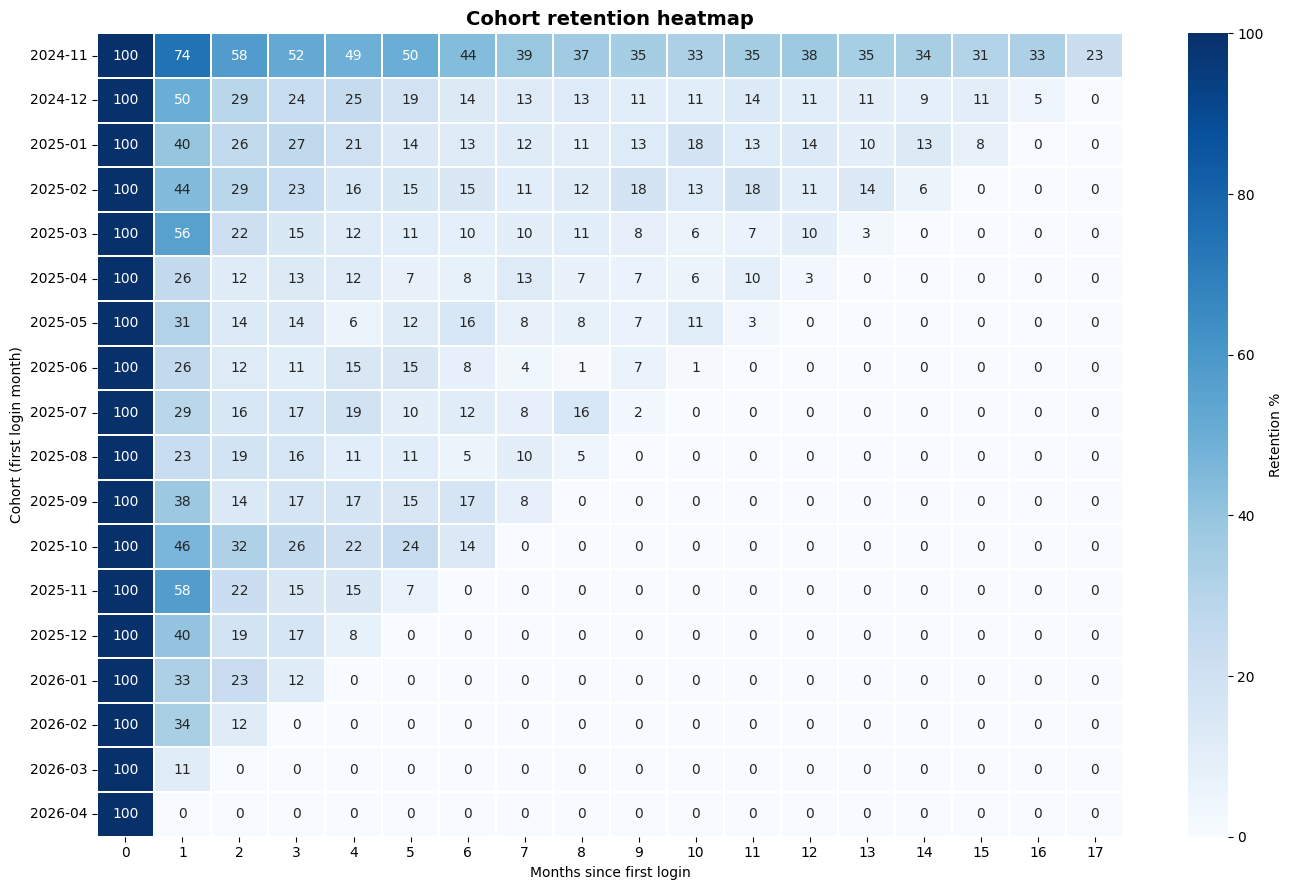

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 3 — Cohort retention heatmap
# ─────────────────────────────────────────────────────────────────────────────
df['cohort'] = df['first_seen'].dt.to_period('M')
df['period']  = df['timestamp'].dt.to_period('M')
df['age']     = (df['period'] - df['cohort']).apply(lambda x: x.n)

cohort_sizes = df.groupby('cohort')['id'].nunique()
retention = (
    df.groupby(['cohort', 'age'])['id']
    .nunique()
    .unstack(fill_value=0)
    .divide(cohort_sizes, axis=0)
    * 100
)

fig, ax = plt.subplots(figsize=(14, max(4, len(retention) * 0.5)))
sns.heatmap(
    retention,
    ax=ax,
    annot=True, fmt='.0f',
    cmap='Blues',
    vmin=0, vmax=100,
    linewidths=0.3,
    cbar_kws={'label': 'Retention %'},
)
ax.set_xlabel('Months since first login')
ax.set_ylabel('Cohort (first login month)')
ax.set_title('Cohort retention heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cohort_retention.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
HOUSEHOLD_QUERY = """SELECT hh.id, hh.resident_count, hh.house_type, hh.square_meters_cat
FROM usage.vw_households hh
WHERE hh.account_status = 'Active'"""

In [14]:
households = wr.athena.read_sql_query(
            sql=HOUSEHOLD_QUERY,
            database="usage",
            s3_output="s3://slimwonen-athena-queries/",
            workgroup="primary",
            boto3_session=session,
        )

In [15]:
HOUSE_TYPE_MAPPING = {
    'Detached house': 'detached', 
    'Corner house': 'corner', 
    'Semi-detached house': 'semi-detached', 
    'rowhouse': 'terraced',
    'Terraced house': 'terraced',
    'Apartment': 'apartment',
    'Hoekwoning': 'corner',
    'Twee-onder-een-kap woning': 'semi-detached',
    'Appartement': 'apartment',
    'Tussenwoning': 'terraced',
    'Vrijstaande woning': 'detached',
    'Terraced House': 'terraced',
}
households['house_type'] = households['house_type'].replace(HOUSE_TYPE_MAPPING)

In [16]:
households['house_type'].value_counts()

house_type
apartment        7109
detached         7048
terraced         6286
semi-detached    5648
corner           3843
Standplaats         1
Name: count, dtype: Int64

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Merge usage counts into user info ────────────────────────────────────────
logins_per_user = df.groupby('id').size().rename('n_logins')
users = households.join(logins_per_user, on='id').fillna({'n_logins': 0})
users['n_logins'] = users['n_logins'].astype(int)

# ── Activity segments ─────────────────────────────────────────────────────────
def activity_segment(n):
    if n <= 2:  return 'inactive'    # ← your benchmark group
    if n <= 10: return 'occasional'
    return 'active'

users['segment'] = users['n_logins'].apply(activity_segment)

# ── Handle NA in house_type ───────────────────────────────────────────────────
users['house_type_clean'] = users['house_type'].fillna('unknown')

# ── Summary table: house_type × segment ──────────────────────────────────────
summary = (
    users
    .groupby(['house_type_clean', 'segment'])
    .agg(
        n_users     = ('id', 'count'),
        median_logins = ('n_logins', 'median'),
        mean_logins   = ('n_logins', 'mean'),
    )
    .unstack('segment')
    .fillna(0)
)
summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index()
print(summary.to_string(index=False))

house_type_clean  n_users_active  n_users_inactive  n_users_occasional  median_logins_active  median_logins_inactive  median_logins_occasional  mean_logins_active  mean_logins_inactive  mean_logins_occasional
     Standplaats             0.0               0.0                 1.0                   0.0                     0.0                       6.0            0.000000              0.000000                6.000000
       apartment           419.0            6313.0               377.0                  51.0                     0.0                       5.0          151.780430              0.076034                5.448276
          corner           491.0            2927.0               425.0                  35.0                     0.0                       5.0          110.826884              0.141783                5.501176
        detached          1069.0            5112.0               867.0                  41.0                     0.0                       5.0          112.493920  

In [18]:
# ── Benchmark group: inactive users (≤2 logins) ───────────────────────────────
# Only house_type groups where inactive users are numerous enough to be a
# stable reference. Require at least MIN_N inactive users per house_type.
MIN_N = 30  # tune to your dataset size

inactive_counts = (
    users[users['segment'] == 'inactive']
    .groupby('house_type_clean')['id'].count()
    .rename('n_inactive')
)

valid_benchmark_types = inactive_counts[inactive_counts >= MIN_N].index.tolist()

benchmark = users[
    (users['segment'] == 'inactive') &
    (users['house_type_clean'].isin(valid_benchmark_types))
].copy()

active = users[
    (users['segment'] == 'active') &
    (users['house_type_clean'].isin(valid_benchmark_types))
].copy()

print(f"Benchmark group : {len(benchmark):,} users across {len(valid_benchmark_types)} house types")
print(f"Active group    : {len(active):,} users across same house types")
print(f"Excluded types  : {users['house_type_clean'].nunique() - len(valid_benchmark_types)} (too few inactive users)")

Benchmark group : 25,648 users across 6 house types
Active group    : 4,191 users across same house types
Excluded types  : 1 (too few inactive users)


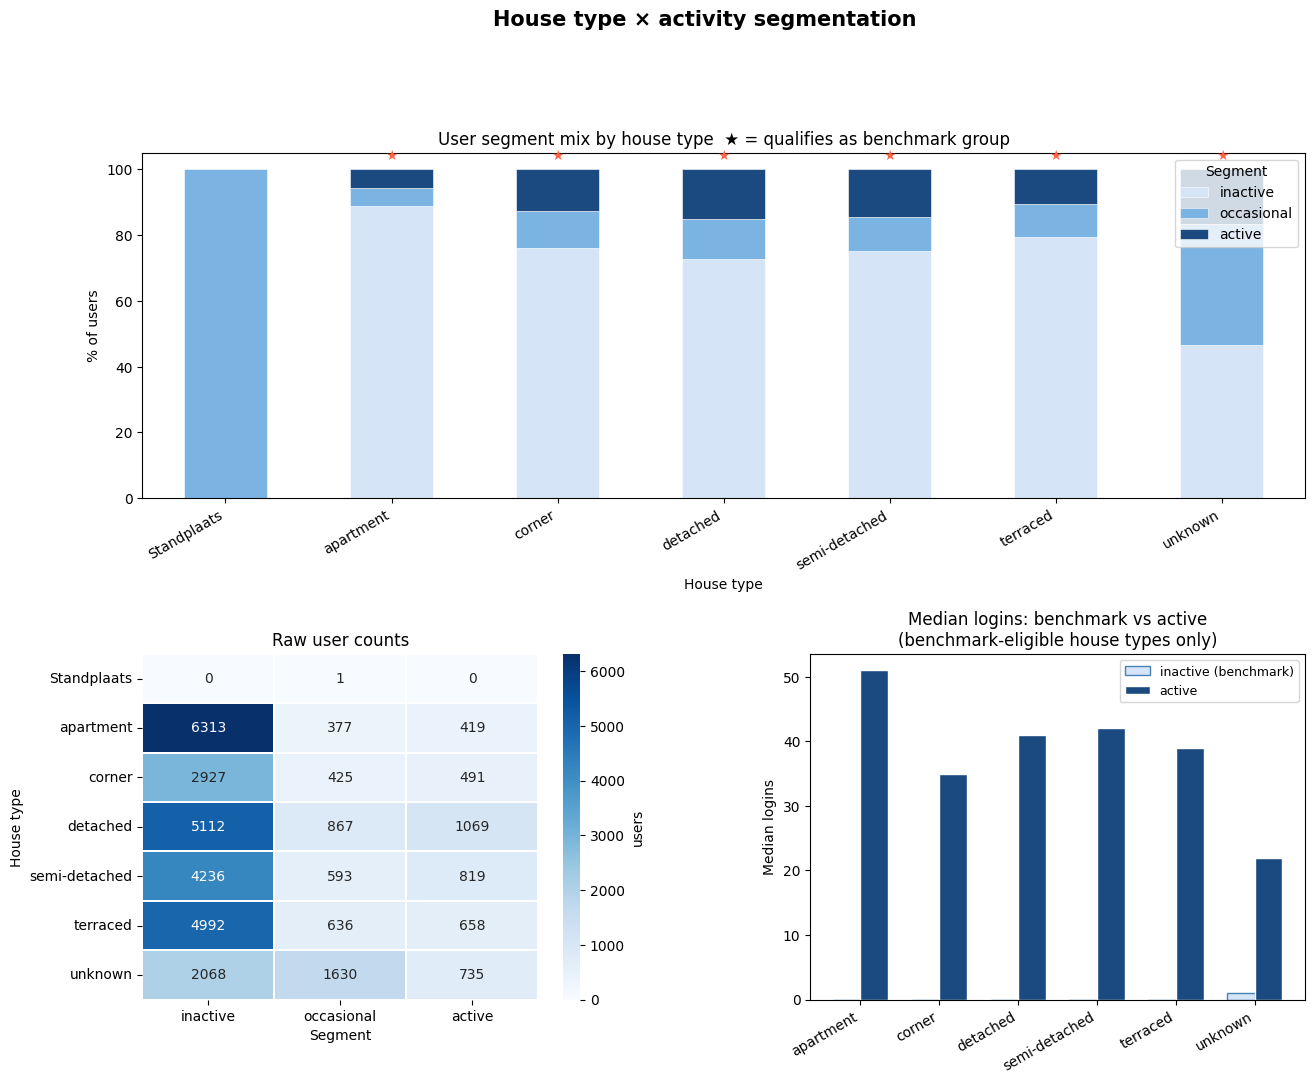

In [19]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 11))
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

seg_colors = {'inactive': '#d6e4f7', 'occasional': '#7bb4e3', 'active': '#1a4a80'}
seg_order  = ['inactive', 'occasional', 'active']

# ── Plot 1: stacked bar — user count per house_type, coloured by segment ──────
ax1 = fig.add_subplot(gs[0, :])  # full width
pivot = (
    users.groupby(['house_type_clean', 'segment'])['id']
    .count()
    .unstack('segment')
    .reindex(columns=seg_order)
    .fillna(0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind='bar', stacked=True, ax=ax1,
               color=[seg_colors[s] for s in seg_order],
               edgecolor='white', linewidth=0.4)

# Overlay: mark house_types included in benchmark with a star
for i, ht in enumerate(pivot_pct.index):
    if ht in valid_benchmark_types:
        ax1.text(i, 102, '★', ha='center', va='bottom', fontsize=10, color='tomato')

ax1.set_xlabel('House type')
ax1.set_ylabel('% of users')
ax1.set_title('User segment mix by house type  ★ = qualifies as benchmark group')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=30, ha='right')
ax1.legend(title='Segment', loc='upper right')

# ── Plot 2: raw counts heatmap ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
count_pivot = (
    users.groupby(['house_type_clean', 'segment'])['id']
    .count()
    .unstack('segment')
    .reindex(columns=seg_order)
    .fillna(0)
    .astype(int)
)
sns.heatmap(count_pivot, ax=ax2, cmap='Blues', annot=True, fmt='d',
            linewidths=0.3, cbar_kws={'label': 'users'})
ax2.set_title('Raw user counts')
ax2.set_xlabel('Segment')
ax2.set_ylabel('House type')

# ── Plot 3: median logins — active vs inactive per house_type ─────────────────
ax3 = fig.add_subplot(gs[1, 1])
medians = (
    users[users['house_type_clean'].isin(valid_benchmark_types)]
    .groupby(['house_type_clean', 'segment'])['n_logins']
    .median()
    .unstack('segment')
    [['inactive', 'active']]
)
x = np.arange(len(medians))
w = 0.35
ax3.bar(x - w/2, medians['inactive'], w, label='inactive (benchmark)',
        color=seg_colors['inactive'], edgecolor='steelblue')
ax3.bar(x + w/2, medians['active'],   w, label='active',
        color=seg_colors['active'], edgecolor='white')
ax3.set_xticks(x)
ax3.set_xticklabels(medians.index, rotation=30, ha='right')
ax3.set_ylabel('Median logins')
ax3.set_title('Median logins: benchmark vs active\n(benchmark-eligible house types only)')
ax3.legend(fontsize=9)

plt.suptitle('House type × activity segmentation', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('segmentation.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# ── Final export: clean benchmark and active frames ready for analysis ─────────
print("\n── Benchmark group (inactive, ≤2 logins) ──")
print(benchmark.groupby('house_type_clean')['id'].count().rename('n_users').to_string())

print("\n── Active group ──")
print(active.groupby('house_type_clean')['id'].count().rename('n_users').to_string())

# These two dataframes are ready for downstream analysis:
#   benchmark  → reference / control group
#   active     → group to compare against benchmark


── Benchmark group (inactive, ≤2 logins) ──
house_type_clean
apartment        6313
corner           2927
detached         5112
semi-detached    4236
terraced         4992
unknown          2068

── Active group ──
house_type_clean
apartment         419
corner            491
detached         1069
semi-detached     819
terraced          658
unknown           735


## Alternative 'active' definition: recurring logins

Instead of a raw login-count threshold, we classify users by how *consistently* they return.
Key metrics per user:
- **`n_months_active`** — distinct calendar months with ≥1 login
- **`span_months`** — inclusive months between first and last login month
- **`recurrence_rate`** — `n_months_active / span_months` (1.0 = logged in every month in their lifespan)

Candidate groups (all require `span_months ≥ 2` to exclude one-time users):
| Label | Criterion | Interpretation |
|---|---|---|
| monthly | rate ≥ 0.80 | logged in almost every month |
| bi-monthly | rate ≥ 0.40, span ≥ 3 | at least once every ~2-3 months |
| quarterly | rate ≥ 0.25, span ≥ 4 | at least once per quarter |


In [54]:
# ── Per-user recurring login metrics ─────────────────────────────────────────
TOTAL_USERS = len(users)
MIN_PCT = 0.05  # minimum group size threshold

user_months = (
    df.assign(month=df['timestamp'].dt.to_period('M'))
    .groupby('id')['month']
    .agg(
        n_months_active=lambda s: s.nunique(),
        first_month='min',
        last_month='max',
    )
)
# user_months['span_months'] = (
#     (user_months['last_month'] - user_months['first_month'])
#     .apply(lambda x: x.n) + 1
# )

period_end = pd.to_datetime(datetime(2026,3,1)).to_period('M')
user_months['span_months'] = (
    (period_end - user_months['first_month'])
    .apply(lambda x: x.n) + 1
)

user_months['recurrence_rate'] = (
    user_months['n_months_active'] / user_months['span_months']
)

# Merge into users (users with zero logins get 0 for all metrics)
users2 = users.join(user_months, on='id')
users2[['n_months_active', 'span_months', 'recurrence_rate']] = (
    users2[['n_months_active', 'span_months', 'recurrence_rate']].fillna(0)
)

print(f"Total users: {TOTAL_USERS:,}  |  5% threshold = {TOTAL_USERS * MIN_PCT:,.0f} users\n")

# ── Distribution of span_months among users who logged in at all ──────────────
has_logins = users2[users2['span_months'] > 0]
print(f"Users with ≥1 login: {len(has_logins):,} ({len(has_logins)/TOTAL_USERS:.1%}): others may have activated before and never logged in the study period\n")
print("span_months distribution (users with ≥1 login):")
span_dist = has_logins['span_months'].value_counts().sort_index()
span_pct  = (span_dist / TOTAL_USERS * 100).round(1)
print(pd.DataFrame({'n_users': span_dist, 'pct_of_total': span_pct}).to_string())


Total users: 34,368  |  5% threshold = 1,718 users

Users with ≥1 login: 12,487 (36.3%): others may have activated before and never logged in the study period

span_months distribution (users with ≥1 login):
             n_users  pct_of_total
span_months                       
1.0              116           0.3
2.0               95           0.3
3.0              168           0.5
4.0              674           2.0
5.0             1826           5.3
6.0               73           0.2
7.0               67           0.2
8.0              124           0.4
9.0              115           0.3
10.0              69           0.2
11.0             153           0.4
12.0             708           2.1
13.0             604           1.8
14.0             288           0.8
15.0             715           2.1
16.0            3532          10.3
17.0            3160           9.2


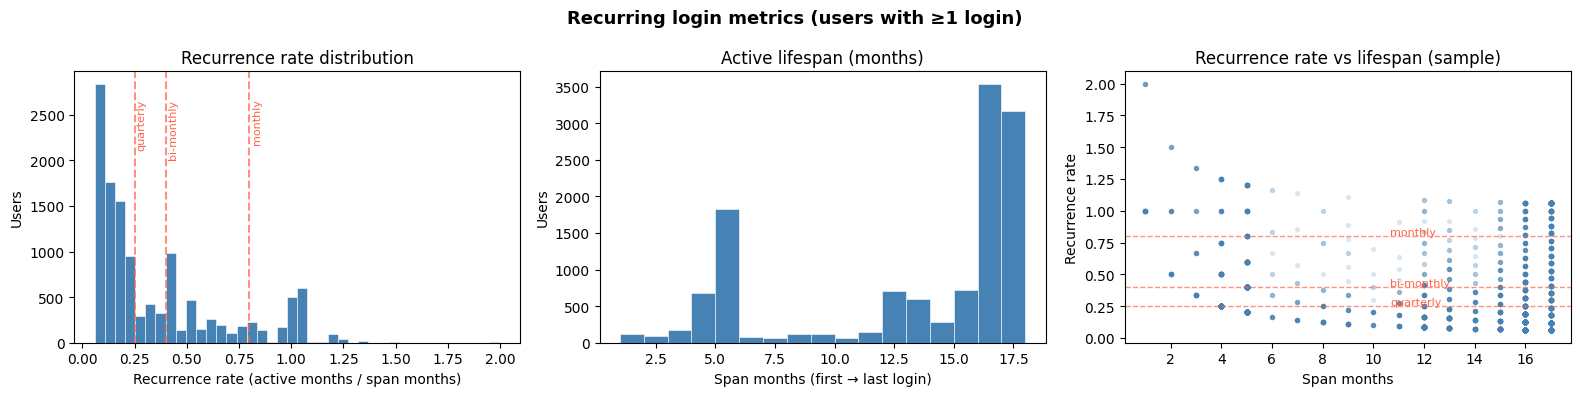

In [55]:
# ── Visualise recurrence_rate and span_months distributions ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Recurring login metrics (users with ≥1 login)', fontsize=13, fontweight='bold')

active_users = has_logins  # shorthand

# Left: recurrence_rate histogram
ax = axes[0]
ax.hist(active_users['recurrence_rate'], bins=40, color='steelblue', edgecolor='white', linewidth=0.4)
for rate, label in [(0.25, 'quarterly'), (0.40, 'bi-monthly'), (0.80, 'monthly')]:
    ax.axvline(rate, color='tomato', linestyle='--', alpha=0.7)
    ax.text(rate + 0.01, ax.get_ylim()[1] * 0.9, label, fontsize=8, color='tomato', rotation=90, va='top')
ax.set_xlabel('Recurrence rate (active months / span months)')
ax.set_ylabel('Users')
ax.set_title('Recurrence rate distribution')

# Middle: span_months histogram
ax = axes[1]
ax.hist(active_users['span_months'], bins=range(1, int(active_users['span_months'].max()) + 2),
        color='steelblue', edgecolor='white', linewidth=0.4)
ax.set_xlabel('Span months (first → last login)')
ax.set_ylabel('Users')
ax.set_title('Active lifespan (months)')

# Right: scatter recurrence_rate vs n_months_active (random sample for speed)
ax = axes[2]
sample = active_users.sample(min(5000, len(active_users)), random_state=42)
ax.scatter(sample['span_months'], sample['recurrence_rate'],
           alpha=0.15, s=8, color='steelblue')
for rate, label in [(0.25, 'quarterly'), (0.40, 'bi-monthly'), (0.80, 'monthly')]:
    ax.axhline(rate, color='tomato', linestyle='--', alpha=0.7, linewidth=1)
    ax.text(ax.get_xlim()[1] * 0.6, rate + 0.01, label, fontsize=8, color='tomato')
ax.set_xlabel('Span months')
ax.set_ylabel('Recurrence rate')
ax.set_title('Recurrence rate vs lifespan (sample)')

plt.tight_layout()
plt.show()


In [56]:
# ── Group size table: test all candidate thresholds ───────────────────────────
# Each candidate: (label, min_recurrence_rate, min_span_months)
candidates = [
    ('monthly',    0.80, 2),
    ('bi-monthly', 0.40, 3),
    ('quarterly',  0.25, 4),
]

print(f"{'Label':<14} {'min_rate':>9} {'min_span':>9} {'n_users':>9} {'% total':>8}  meets 5% threshold?")
print("-" * 65)
for label, min_rate, min_span in candidates:
    mask = (
        (users2['recurrence_rate'] >= min_rate) &
        (users2['span_months'] >= min_span)
    )
    n = mask.sum()
    pct = n / TOTAL_USERS
    flag = "YES" if pct >= MIN_PCT else "NO "
    print(f"{label:<14} {min_rate:>9.2f} {min_span:>9d} {n:>9,} {pct:>8.1%}  {flag}")

print()
# Also show overlap with existing 'active' segment (>10 logins)
print("Overlap with original 'active' segment (>10 logins):")
print(f"{'Label':<14} {'in both':>9} {'recur only':>11} {'count only':>11}")
print("-" * 50)
orig_active = users2['segment'] == 'active'
for label, min_rate, min_span in candidates:
    mask = (
        (users2['recurrence_rate'] >= min_rate) &
        (users2['span_months'] >= min_span)
    )
    both       = (mask & orig_active).sum()
    recur_only = (mask & ~orig_active).sum()
    count_only = (~mask & orig_active).sum()
    print(f"{label:<14} {both:>9,} {recur_only:>11,} {count_only:>11,}")


Label           min_rate  min_span   n_users  % total  meets 5% threshold?
-----------------------------------------------------------------
monthly             0.80         2     1,743     5.1%  YES
bi-monthly          0.40         3     4,136    12.0%  YES
quarterly           0.25         4     5,688    16.6%  YES

Overlap with original 'active' segment (>10 logins):
Label            in both  recur only  count only
--------------------------------------------------
monthly            1,651          92       2,540
bi-monthly         3,019       1,117       1,172
quarterly          3,656       2,032         535


In [57]:
# ── Assign recurrence label to every user and inspect segment breakdown ────────
# Pick the strictest label each user qualifies for
def recurrence_label(row):
    rate  = row['recurrence_rate']
    span  = row['span_months']
    if span < 2:
        return 'non-recurring'   # single month or no logins
    if rate >= 0.80:
        return 'monthly'
    if rate >= 0.40 and span >= 3:
        return 'bi-monthly'
    if rate >= 0.25 and span >= 4:
        return 'quarterly'
    return 'non-recurring'

users2['recurrence_label'] = users2.apply(recurrence_label, axis=1)

# ── Summary ───────────────────────────────────────────────────────────────────
summary = (
    users2.groupby('recurrence_label')
    .agg(
        n_users        = ('id', 'count'),
        median_logins  = ('n_logins', 'median'),
        median_months  = ('n_months_active', 'median'),
        median_span    = ('span_months', 'median'),
        median_rate    = ('recurrence_rate', 'median'),
    )
)
summary['pct_total'] = (summary['n_users'] / TOTAL_USERS * 100).round(1)
label_order = ['monthly', 'bi-monthly', 'quarterly', 'non-recurring']
summary = summary.reindex(label_order)
print(summary.to_string())

print(f"\nTotal: {TOTAL_USERS:,}")
print(f"5% threshold: {TOTAL_USERS * 0.05:,.0f} users")


                  n_users  median_logins  median_months  median_span  median_rate  pct_total
recurrence_label                                                                            
monthly              1743          121.0           16.0         17.0     1.000000        5.1
bi-monthly           2432           14.0            6.0         12.0     0.500000        7.1
quarterly            1618            9.0            4.0         16.0     0.294118        4.7
non-recurring       28575            0.0            0.0          0.0     0.000000       83.1

Total: 34,368
5% threshold: 1,718 users


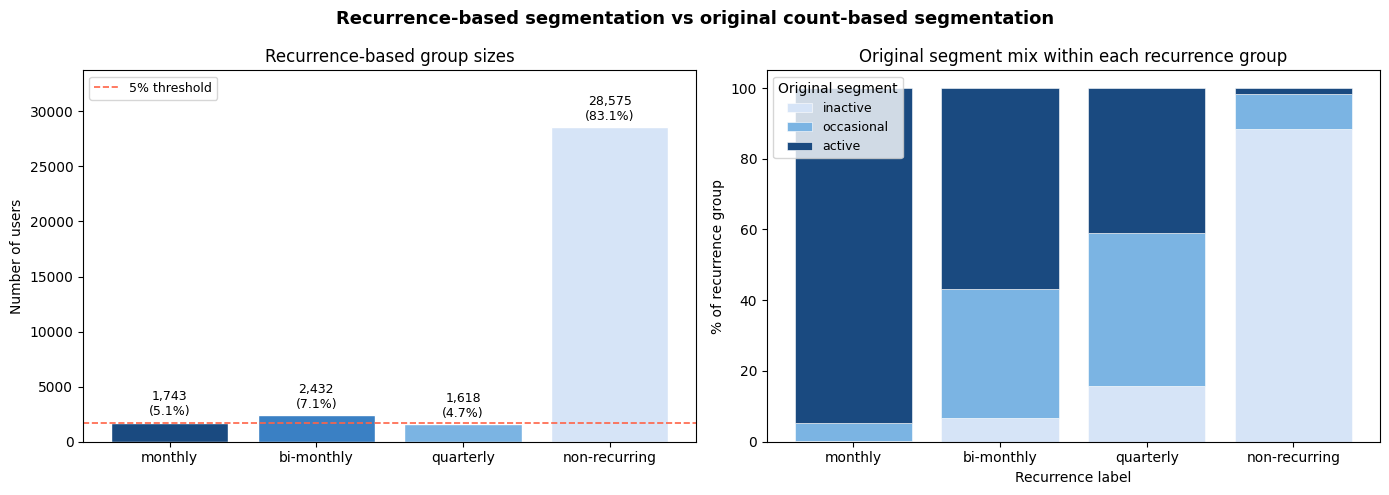


Groups meeting the ≥5% threshold:
  ✓ monthly: 1,743 users (5.1%)
  ✓ bi-monthly: 2,432 users (7.1%)
  ✓ non-recurring: 28,575 users (83.1%)


In [58]:
# ── Visual comparison: recurrence groups vs original active/inactive ───────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Recurrence-based segmentation vs original count-based segmentation',
             fontsize=13, fontweight='bold')

recur_colors = {
    'monthly':       '#1a4a80',
    'bi-monthly':    '#3a80c4',
    'quarterly':     '#7bb4e3',
    'non-recurring': '#d6e4f7',
}
recur_order = ['monthly', 'bi-monthly', 'quarterly', 'non-recurring']

# Left: recurrence group sizes
ax = axes[0]
counts = users2['recurrence_label'].value_counts().reindex(recur_order, fill_value=0)
bars = ax.bar(recur_order, counts, color=[recur_colors[l] for l in recur_order], edgecolor='white')
ax.bar_label(bars, labels=[f"{v:,}\n({v/TOTAL_USERS:.1%})" for v in counts], padding=3, fontsize=9)
ax.axhline(TOTAL_USERS * MIN_PCT, color='tomato', linestyle='--', linewidth=1.2, label='5% threshold')
ax.set_ylabel('Number of users')
ax.set_title('Recurrence-based group sizes')
ax.legend(fontsize=9)
ax.set_ylim(0, counts.max() * 1.18)

# Right: cross-tab — recurrence label vs original segment
ax = axes[1]
cross = (
    users2.groupby(['recurrence_label', 'segment'])['id']
    .count()
    .unstack('segment')
    .reindex(recur_order)
    .fillna(0)
    .astype(int)
)
# show as % of row
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
orig_colors = {'inactive': '#d6e4f7', 'occasional': '#7bb4e3', 'active': '#1a4a80'}
bottom = np.zeros(len(cross_pct))
for seg, color in orig_colors.items():
    if seg in cross_pct.columns:
        vals = cross_pct[seg].values
        bars = ax.bar(recur_order, vals, bottom=bottom,
                      label=seg, color=color, edgecolor='white', linewidth=0.4)
        bottom += vals
ax.set_ylabel('% of recurrence group')
ax.set_xlabel('Recurrence label')
ax.set_title('Original segment mix within each recurrence group')
ax.legend(title='Original segment', fontsize=9)

plt.tight_layout()
plt.show()

# ── Which recurrence group(s) meet the 5% threshold? ──────────────────────────
print("\nGroups meeting the ≥5% threshold:")
for label in recur_order:
    n = (users2['recurrence_label'] == label).sum()
    pct = n / TOTAL_USERS
    if pct >= MIN_PCT:
        print(f"  ✓ {label}: {n:,} users ({pct:.1%})")


In [59]:
# ── Assign exclusive recurrence label (strictest match wins) ─────────────────
# Each user gets the one level they best qualify for.
# monthly > bi-monthly > quarterly > non-recurring

def assign_recurrence_excl(row):
    rate = row['recurrence_rate']
    span = row['span_months']
    if rate >= 0.80 and span >= 2:
        return 'monthly'
    if rate >= 0.40 and span >= 3:
        return 'bi-monthly'
    if rate >= 0.25 and span >= 4:
        return 'quarterly'
    return 'non-recurring'

users2['recurrence_excl'] = users2.apply(assign_recurrence_excl, axis=1)

recur_order_excl = ['monthly', 'bi-monthly', 'quarterly', 'non-recurring']
counts = users2['recurrence_excl'].value_counts().reindex(recur_order_excl, fill_value=0)
print(f"{'Label':<16} {'n_users':>8}  {'% total':>8}")
print("-" * 36)
for label in recur_order_excl:
    n = counts[label]
    print(f"{label:<16} {n:>8,}  {n/TOTAL_USERS:>8.1%}")
print(f"{'TOTAL':<16} {TOTAL_USERS:>8,}  {'100.0%':>8}")


Label             n_users   % total
------------------------------------
monthly             1,743      5.1%
bi-monthly          2,432      7.1%
quarterly           1,618      4.7%
non-recurring      28,575     83.1%
TOTAL              34,368    100.0%


/var/folders/fr/dynq2jt113v40q17r07m78d40000gn/T/ipykernel_4392/1425120005.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ht_order, rotation=30, ha='right')


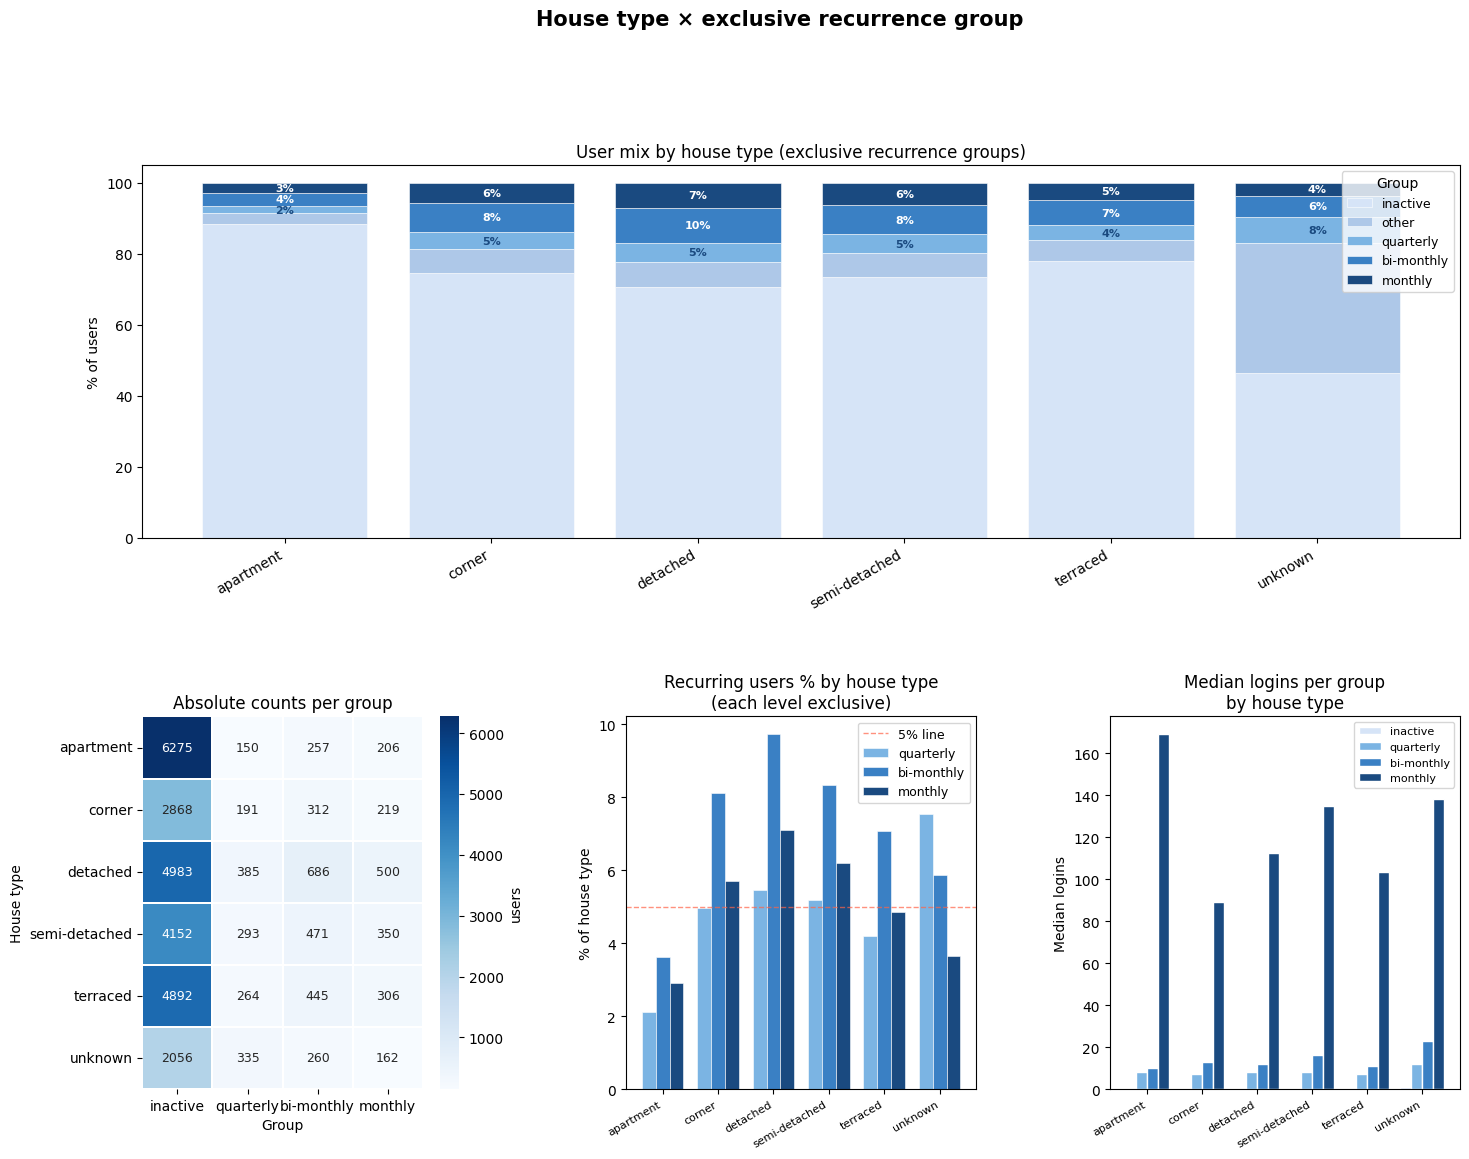


Group            n_users   % total   meets 5%?
------------------------------------------------
inactive          25,226     73.4%         YES
other              3,349      9.7%         YES
quarterly          1,618      4.7%          NO
bi-monthly         2,431      7.1%         YES
monthly            1,743      5.1%         YES


In [60]:
# ── House type × exclusive recurrence comparison (style of cell 19) ───────────
# Groups shown per house type:
#   inactive      : original benchmark (<=2 logins)  — always the reference
#   quarterly     : exclusive quarterly users (rate>=0.25, span>=4, not bi/monthly)
#   bi-monthly    : exclusive bi-monthly users (rate>=0.40, span>=3, not monthly)
#   monthly       : exclusive monthly users (rate>=0.80, span>=2)
#   other         : has logins but no recurrence pattern

seg_colors_excl = {
    'inactive':    '#d6e4f7',
    'other':       '#aec8e8',
    'quarterly':   '#7bb4e3',
    'bi-monthly':  '#3a80c4',
    'monthly':     '#1a4a80',
}
seg_order_excl = ['inactive', 'other', 'quarterly', 'bi-monthly', 'monthly']
ht_order = ['apartment', 'corner', 'detached', 'semi-detached', 'terraced', 'unknown']

# Build combined classification: recurrence_excl, but inactive overrides 'non-recurring'
tmp = users2[users2['house_type_clean'].isin(ht_order)].copy()
tmp['grp'] = tmp['recurrence_excl']
tmp.loc[tmp['segment'] == 'inactive', 'grp'] = 'inactive'   # benchmark overrides non-recurring
tmp.loc[(tmp['segment'] == 'inactive') & (tmp['recurrence_excl'] != 'non-recurring'), 'grp'] = tmp['recurrence_excl']
# edge case: if an inactive user (<=2 logins) somehow meets recurrence → keep recurrence label
tmp['grp'] = tmp['grp'].replace('non-recurring', 'other')

fig = plt.figure(figsize=(17, 12))
gs  = GridSpec(2, 3, figure=fig, hspace=0.48, wspace=0.38)
fig.suptitle('House type × exclusive recurrence group', fontsize=15, fontweight='bold', y=1.01)

# ── Plot 1: stacked % bar — full width top ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
pivot = (
    tmp.groupby(['house_type_clean', 'grp'])['id']
    .count()
    .unstack('grp')
    .reindex(index=ht_order, columns=seg_order_excl)
    .fillna(0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(ht_order))
for seg in seg_order_excl:
    vals = pivot_pct[seg].values if seg in pivot_pct.columns else np.zeros(len(ht_order))
    ax1.bar(ht_order, vals, bottom=bottom, label=seg,
            color=seg_colors_excl[seg], edgecolor='white', linewidth=0.4)
    bottom += vals

# annotate each recurring group % on top of bar
for seg, color in [('monthly', 'white'), ('bi-monthly', 'white'), ('quarterly', '#1a4a80')]:
    if seg not in pivot_pct.columns:
        continue
    cum_below = pivot_pct[seg_order_excl[:seg_order_excl.index(seg)]].sum(axis=1)
    mid = cum_below + pivot_pct[seg] / 2
    for i, ht in enumerate(ht_order):
        v = pivot_pct[seg].iloc[i]
        if v >= 1.5:
            ax1.text(i, mid.iloc[i], f"{v:.0f}%", ha='center', va='center',
                     fontsize=8, color=color, fontweight='bold')

ax1.set_ylabel('% of users')
ax1.set_title('User mix by house type (exclusive recurrence groups)')
ax1.set_xticklabels(ht_order, rotation=30, ha='right')
ax1.legend(title='Group', fontsize=9, loc='upper right')

# ── Plot 2: raw counts heatmap — inactive vs each recurring level ─────────────
ax2 = fig.add_subplot(gs[1, 0])
heatmap_cols = ['inactive', 'quarterly', 'bi-monthly', 'monthly']
count_pivot = (
    tmp.groupby(['house_type_clean', 'grp'])['id']
    .count()
    .unstack('grp')
    .reindex(index=ht_order, columns=heatmap_cols)
    .fillna(0)
    .astype(int)
)
sns.heatmap(count_pivot, ax=ax2, cmap='Blues', annot=True, fmt='d',
            linewidths=0.3, cbar_kws={'label': 'users'}, annot_kws={'size': 9})
ax2.set_title('Absolute counts per group')
ax2.set_xlabel('Group')
ax2.set_ylabel('House type')

# ── Plot 3: % recurring per house type — each level as lines ─────────────────
ax3 = fig.add_subplot(gs[1, 1])
recur_levels = ['quarterly', 'bi-monthly', 'monthly']
level_colors = {'quarterly': '#7bb4e3', 'bi-monthly': '#3a80c4', 'monthly': '#1a4a80'}
x = np.arange(len(ht_order))
w = 0.25
offsets = [-w, 0, w]
for i, (level, offset) in enumerate(zip(recur_levels, offsets)):
    vals = pivot_pct[level].values if level in pivot_pct.columns else np.zeros(len(ht_order))
    bars = ax3.bar(x + offset, vals, w, label=level,
                   color=level_colors[level], edgecolor='white', linewidth=0.4)
ax3.set_xticks(x)
ax3.set_xticklabels(ht_order, rotation=30, ha='right', fontsize=8)
ax3.set_ylabel('% of house type')
ax3.set_title('Recurring users % by house type\n(each level exclusive)')
ax3.legend(fontsize=9)
ax3.axhline(5, color='tomato', linestyle='--', linewidth=1, alpha=0.7, label='5% line')
ax3.legend(fontsize=9)

# ── Plot 4: median logins — inactive vs each recurring level ──────────────────
ax4 = fig.add_subplot(gs[1, 2])
medians = (
    tmp[tmp['grp'].isin(['inactive', 'quarterly', 'bi-monthly', 'monthly'])]
    .groupby(['house_type_clean', 'grp'])['n_logins']
    .median()
    .unstack('grp')
    .reindex(index=ht_order, columns=['inactive', 'quarterly', 'bi-monthly', 'monthly'])
)
x = np.arange(len(ht_order))
w = 0.20
med_colors = ['#d6e4f7', '#7bb4e3', '#3a80c4', '#1a4a80']
for i, (col, color) in enumerate(zip(['inactive', 'quarterly', 'bi-monthly', 'monthly'], med_colors)):
    if col in medians.columns:
        offset = (i - 1.5) * w
        ax4.bar(x + offset, medians[col].fillna(0), w, label=col, color=color, edgecolor='white')
ax4.set_xticks(x)
ax4.set_xticklabels(ht_order, rotation=30, ha='right', fontsize=8)
ax4.set_ylabel('Median logins')
ax4.set_title('Median logins per group\nby house type')
ax4.legend(fontsize=8)

plt.savefig('recurrence_housetype_exclusive.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Group size summary ────────────────────────────────────────────────────────
print(f"\n{'Group':<14} {'n_users':>9}  {'% total':>8}  {'meets 5%?':>10}")
print("-" * 48)
for grp in seg_order_excl:
    n = (tmp['grp'] == grp).sum()
    pct = n / TOTAL_USERS
    flag = 'YES' if pct >= 0.05 else 'NO'
    print(f"{grp:<14} {n:>9,}  {pct:>8.1%}  {flag:>10}")


## Collect usage data

In [34]:
USAGE_QUERY = """SELECT du.household_id as id, du.date, du.usage as gas
FROM usage.vw_daily_usage du
WHERE du.date >= '2024-11-01' AND du.date < '2026-04-01'
AND du.type = 'gas'"""

In [ ]:
gas_usage = wr.athena.read_sql_query(
    sql=USAGE_QUERY,
    database="usage",
    s3_output="s3://slimwonen-athena-queries/",
    workgroup="primary",
    boto3_session=session,
)

In [46]:
users2.sample(10)

,id,resident_count,house_type,square_meters_cat,n_logins,segment,house_type_clean,n_months_active,first_month,last_month,span_months,recurrence_rate
27060,b8d1f140-0ea3-444c-ac66-51c7495b6b65,2.0,corner,100-120 m2,0,inactive,corner,0.0,NaT,NaT,0.0,0.000000
5932,fa81a675-0795-4fae-bd47-2410c3d16a99,NaN,detached,> 200m2,2,inactive,detached,1.0,2025-11,2025-11,1.0,1.000000
27270,7d6a30ce-78b8-47a2-8982-39fee21e16aa,1.0,apartment,100-120 m2,0,inactive,apartment,0.0,NaT,NaT,0.0,0.000000
2279,d075da6a-6b85-487e-b251-ab435bd0999f,4.0,detached,100-120 m2,0,inactive,detached,0.0,NaT,NaT,0.0,0.000000
27140,2c51726a-55d9-4d37-b2d3-05b6cf3f9c13,2.0,terraced,100-120 m2,0,inactive,terraced,0.0,NaT,NaT,0.0,0.000000
6267,88cc10ac-709e-4bbb-8bb4-387930790fc5,2.0,terraced,< 100m2,245,active,terraced,9.0,2024-12,2025-08,9.0,1.000000
10194,38ecbe95-c40c-4eda-a47b-0883e277061e,1.0,detached,< 100m2,0,inactive,detached,0.0,NaT,NaT,0.0,0.000000
24859,043a8078-3db7-4eb3-90fe-16f7a824a723,NaN,<NA>,<NA>,19,active,unknown,4.0,2025-04,2026-03,12.0,0.333333
14166,232304e8-f4b7-4244-a7c9-9128a1201182,5.0,detached,> 200m2,0,inactive,detached,0.0,NaT,NaT,0.0,0.000000
489,1ceb44c9-3028-435e-a999-33358992bffa,1.0,apartment,120-150 m2,0,inactive,apartment,0.0,NaT,NaT,0.0,0.000000


## Gas usage impact: monthly recurring vs inactive users

Compare average daily gas consumption between monthly recurring app users and inactive users (≤2 logins), broken down by house type. The difference serves as a proxy for the app's potential impact on energy behaviour.

In [62]:
# ── Build comparison groups from users2 ───────────────────────────────────────
# monthly  : exclusive recurrence_excl == 'monthly' (rate≥0.80, span≥2)
# inactive : original benchmark segment (≤2 logins)

monthly_ids = users2[users2['recurrence_excl'] == 'monthly'][['id', 'house_type_clean']].copy()
monthly_ids['group'] = 'monthly'

inactive_ids = users2[users2['segment'] == 'inactive'][['id', 'house_type_clean']].copy()
inactive_ids['group'] = 'inactive'

impact_users = pd.concat([monthly_ids, inactive_ids], ignore_index=True)

# ── Merge with gas usage data ─────────────────────────────────────────────────
gas_merged = gas_usage.merge(impact_users, on='id', how='inner')
gas_merged['date'] = pd.to_datetime(gas_merged['date'])

# ── Average daily gas per user (normalises for observation-period length) ──────
user_avg = (
    gas_merged.groupby(['id', 'group', 'house_type_clean'])['gas']
    .mean()
    .reset_index()
    .rename(columns={'gas': 'avg_daily_gas_m3'})
)

# ── Summary statistics: mean ± std and sample size per group × house type ──────
HOUSE_TYPES = ['apartment', 'corner', 'detached', 'semi-detached', 'terraced']

summary = (
    user_avg[user_avg['house_type_clean'].isin(HOUSE_TYPES)]
    .groupby(['house_type_clean', 'group'])['avg_daily_gas_m3']
    .agg(mean='mean', std='std', n='count')
    .reset_index()
)
summary['se'] = summary['std'] / summary['n'] ** 0.5

# Pivot for readability
pivot_mean = summary.pivot(index='house_type_clean', columns='group', values='mean').reindex(HOUSE_TYPES)
pivot_n    = summary.pivot(index='house_type_clean', columns='group', values='n').reindex(HOUSE_TYPES)
pivot_se   = summary.pivot(index='house_type_clean', columns='group', values='se').reindex(HOUSE_TYPES)

# Difference: monthly minus inactive (negative = monthly uses less)
pivot_diff = pivot_mean['monthly'] - pivot_mean['inactive']
pivot_diff_pct = (pivot_diff / pivot_mean['inactive'] * 100).round(1)

result = pd.DataFrame({
    'inactive_mean_m3':  pivot_mean['inactive'].round(3),
    'inactive_n':        pivot_n['inactive'].astype(int),
    'monthly_mean_m3':   pivot_mean['monthly'].round(3),
    'monthly_n':         pivot_n['monthly'].astype(int),
    'diff_m3':           pivot_diff.round(3),
    'diff_pct':          pivot_diff_pct,
})

print("Average daily gas consumption (m³/day) — monthly recurring vs inactive users")
print("=" * 75)
print(result.to_string())


Average daily gas consumption (m³/day) — monthly recurring vs inactive users
                  inactive_mean_m3  inactive_n  monthly_mean_m3  monthly_n  diff_m3  diff_pct
house_type_clean                                                                             
apartment                    1.692        5309            1.251        134   -0.441     -26.1
corner                       2.292        2658            2.122        142   -0.170      -7.4
detached                     3.194        4346            2.672        358   -0.522     -16.3
semi-detached                2.543        3874            2.093        286   -0.451     -17.7
terraced                     1.975        4508            1.760        207   -0.214     -10.9


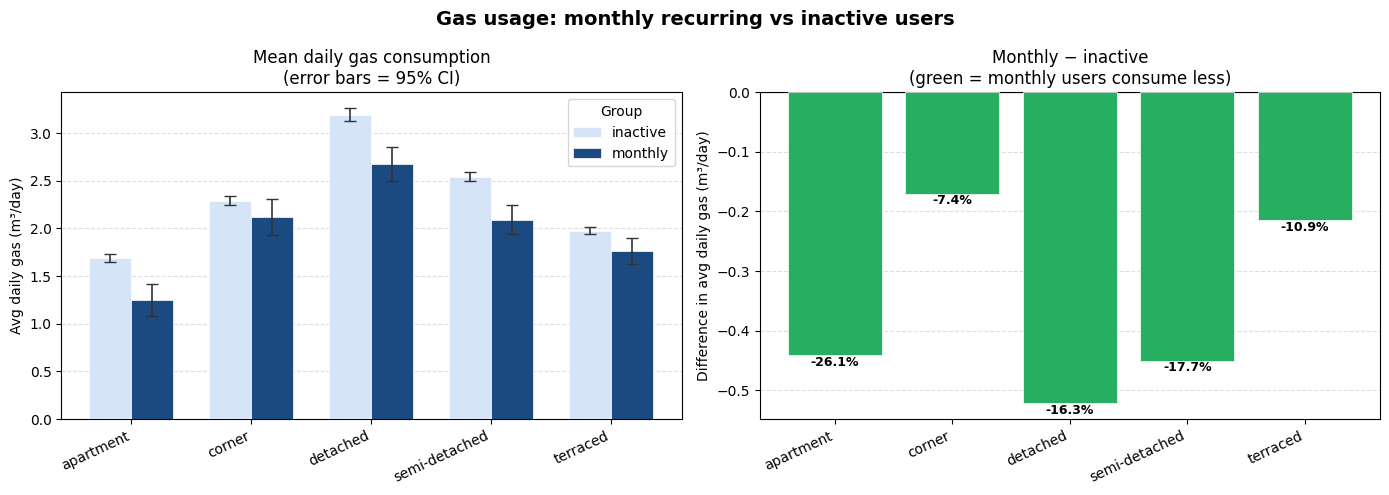

In [63]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gas usage: monthly recurring vs inactive users', fontsize=14, fontweight='bold')

group_colors = {'inactive': '#d6e4f7', 'monthly': '#1a4a80'}
x = np.arange(len(HOUSE_TYPES))
w = 0.35

# ── Left: grouped bar chart — mean daily gas per house type ───────────────────
ax = axes[0]
for i, (grp, color) in enumerate(group_colors.items()):
    means = pivot_mean[grp].values
    errs  = pivot_se[grp].values * 1.96  # 95% CI
    offset = (i - 0.5) * w
    bars = ax.bar(x + offset, means, w, label=grp, color=color,
                  edgecolor='white', linewidth=0.5, zorder=3)
    ax.errorbar(x + offset, means, yerr=errs, fmt='none',
                color='#333', linewidth=1.2, capsize=4, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels(HOUSE_TYPES, rotation=25, ha='right')
ax.set_ylabel('Avg daily gas (m³/day)')
ax.set_title('Mean daily gas consumption\n(error bars = 95% CI)')
ax.legend(title='Group')
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

# ── Right: difference bar (monthly − inactive), coloured by sign ──────────────
ax2 = axes[1]
diffs = pivot_diff.values
diff_colors = ['#c0392b' if d > 0 else '#27ae60' for d in diffs]
bars2 = ax2.bar(x, diffs, color=diff_colors, edgecolor='white', linewidth=0.5, zorder=3)
ax2.axhline(0, color='#333', linewidth=0.8)

for bar, pct in zip(bars2, pivot_diff_pct.values):
    ypos = bar.get_height() if bar.get_height() >= 0 else bar.get_height() - 0.001
    va = 'bottom' if bar.get_height() >= 0 else 'top'
    ax2.text(bar.get_x() + bar.get_width() / 2, ypos,
             f'{pct:+.1f}%', ha='center', va=va, fontsize=9, fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(HOUSE_TYPES, rotation=25, ha='right')
ax2.set_ylabel('Difference in avg daily gas (m³/day)')
ax2.set_title('Monthly − inactive\n(green = monthly users consume less)')
ax2.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig('gas_impact_by_housetype.png', dpi=150, bbox_inches='tight')
plt.show()


## Gas usage impact: bi-monthly and quarterly recurring vs inactive users

Extend the impact analysis to all recurrence tiers. Compare average daily gas consumption for **monthly**, **bi-monthly**, and **quarterly** recurring users against the **inactive** baseline (≤2 logins), broken down by house type.

In [64]:
# ── Build comparison groups from users2 ─────────────────────────────────────
# monthly    : exclusive recurrence_excl == 'monthly'    (rate≥0.80, span≥2)
# bi-monthly : exclusive recurrence_excl == 'bi-monthly' (rate≥0.40, span≥3)
# quarterly  : exclusive recurrence_excl == 'quarterly'  (rate≥0.25, span≥4)
# inactive   : original benchmark segment (≤2 logins)

recur_groups = ['monthly', 'bi-monthly', 'quarterly']
recur_colors_impact = {
    'inactive':   '#d6e4f7',
    'quarterly':  '#7bb4e3',
    'bi-monthly': '#3a80c4',
    'monthly':    '#1a4a80',
}

group_frames = []
for grp in recur_groups:
    tmp = users2[users2['recurrence_excl'] == grp][['id', 'house_type_clean']].copy()
    tmp['group'] = grp
    group_frames.append(tmp)

inactive_ids2 = users2[users2['segment'] == 'inactive'][['id', 'house_type_clean']].copy()
inactive_ids2['group'] = 'inactive'
group_frames.append(inactive_ids2)

impact_users2 = pd.concat(group_frames, ignore_index=True)

# ── Merge with gas usage data ─────────────────────────────────────────────────
gas_merged2 = gas_usage.merge(impact_users2, on='id', how='inner')
gas_merged2['date'] = pd.to_datetime(gas_merged2['date'])

# ── Average daily gas per user ────────────────────────────────────────────────
user_avg2 = (
    gas_merged2.groupby(['id', 'group', 'house_type_clean'])['gas']
    .mean()
    .reset_index()
    .rename(columns={'gas': 'avg_daily_gas_m3'})
)

# ── Summary statistics per group × house type ─────────────────────────────────
HOUSE_TYPES2 = ['apartment', 'corner', 'detached', 'semi-detached', 'terraced']
ALL_GROUPS   = ['inactive', 'quarterly', 'bi-monthly', 'monthly']

summary2 = (
    user_avg2[user_avg2['house_type_clean'].isin(HOUSE_TYPES2)]
    .groupby(['house_type_clean', 'group'])['avg_daily_gas_m3']
    .agg(mean='mean', std='std', n='count')
    .reset_index()
)
summary2['se'] = summary2['std'] / summary2['n'] ** 0.5

pivot_mean2 = summary2.pivot(index='house_type_clean', columns='group', values='mean').reindex(HOUSE_TYPES2)[ALL_GROUPS]
pivot_se2   = summary2.pivot(index='house_type_clean', columns='group', values='se').reindex(HOUSE_TYPES2)[ALL_GROUPS]
pivot_n2    = summary2.pivot(index='house_type_clean', columns='group', values='n').reindex(HOUSE_TYPES2)[ALL_GROUPS]

# Difference vs inactive (negative = recurring tier uses less)
diff_frames = {}
for grp in recur_groups:
    d = pivot_mean2[grp] - pivot_mean2['inactive']
    diff_frames[grp] = d

pivot_diff2     = pd.DataFrame(diff_frames, index=HOUSE_TYPES2)
pivot_diff_pct2 = (pivot_diff2.div(pivot_mean2['inactive'], axis=0) * 100).round(1)

print(pivot_mean2.round(3))
print()
print('Difference vs inactive (m³/day):')
print(pivot_diff2.round(3))
print()
print('Difference vs inactive (%):')
print(pivot_diff_pct2)

group             inactive  quarterly  bi-monthly  monthly
house_type_clean                                          
apartment            1.692      1.313       1.555    1.251
corner               2.292      2.083       2.064    2.122
detached             3.194      2.983       2.822    2.672
semi-detached        2.543      2.337       2.299    2.093
terraced             1.975      1.925       1.793    1.760

Difference vs inactive (m³/day):
               monthly  bi-monthly  quarterly
apartment       -0.441      -0.137     -0.380
corner          -0.170      -0.228     -0.210
detached        -0.522      -0.373     -0.211
semi-detached   -0.451      -0.244     -0.207
terraced        -0.214      -0.182     -0.050

Difference vs inactive (%):
               monthly  bi-monthly  quarterly
apartment        -26.1        -8.1      -22.4
corner            -7.4        -9.9       -9.1
detached         -16.3       -11.7       -6.6
semi-detached    -17.7        -9.6       -8.1
terraced         -

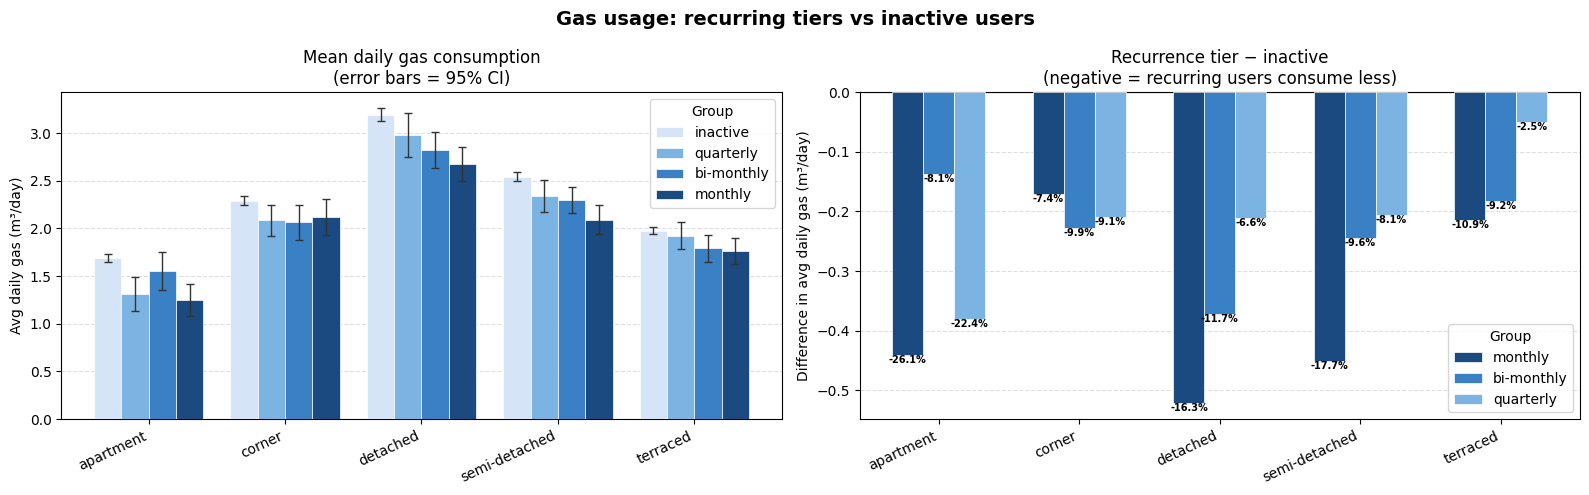

In [65]:
# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Gas usage: recurring tiers vs inactive users', fontsize=14, fontweight='bold')

x  = np.arange(len(HOUSE_TYPES2))
w  = 0.20

# ── Left: grouped bar chart — mean daily gas per house type ───────────────────
ax = axes[0]
for i, grp in enumerate(ALL_GROUPS):
    means  = pivot_mean2[grp].values
    errs   = pivot_se2[grp].values * 1.96  # 95% CI
    offset = (i - 1.5) * w
    bars = ax.bar(x + offset, means, w, label=grp,
                  color=recur_colors_impact[grp],
                  edgecolor='white', linewidth=0.5, zorder=3)
    ax.errorbar(x + offset, means, yerr=errs, fmt='none',
                color='#333', linewidth=1.0, capsize=3, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels(HOUSE_TYPES2, rotation=25, ha='right')
ax.set_ylabel('Avg daily gas (m³/day)')
ax.set_title('Mean daily gas consumption\n(error bars = 95% CI)')
ax.legend(title='Group')
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

# ── Right: difference bars vs inactive, one cluster per recurrence tier ───────
ax2 = axes[1]
n_grps = len(recur_groups)
w2 = 0.22
for i, grp in enumerate(recur_groups):
    diffs = pivot_diff2[grp].values
    pcts  = pivot_diff_pct2[grp].values
    offset = (i - (n_grps - 1) / 2) * w2
    bar_colors = ['#c0392b' if d > 0 else '#27ae60' for d in diffs]
    bars2 = ax2.bar(x + offset, diffs, w2, label=grp,
                    color=recur_colors_impact[grp],
                    edgecolor='white', linewidth=0.5, zorder=3)
    for bar, pct in zip(bars2, pcts):
        h = bar.get_height()
        ypos = h if h >= 0 else h
        va   = 'bottom' if h >= 0 else 'top'
        ax2.text(bar.get_x() + bar.get_width() / 2, ypos,
                 f'{pct:+.1f}%', ha='center', va=va, fontsize=7, fontweight='bold')

ax2.axhline(0, color='#333', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(HOUSE_TYPES2, rotation=25, ha='right')
ax2.set_ylabel('Difference in avg daily gas (m³/day)')
ax2.set_title('Recurrence tier − inactive\n(negative = recurring users consume less)')
ax2.legend(title='Group')
ax2.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig('gas_impact_all_tiers.png', dpi=150, bbox_inches='tight')
plt.show()